In [1]:
#Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [2]:
#Clean TotalCharges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna()

In [3]:
#Verify:

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [4]:
#Create Initial LTV Formula

df["LTV"] = (
    df["MonthlyCharges"]
    * df["tenure"]
)

In [5]:
#Inspect LTV Values

df[
    [
        "customerID",
        "MonthlyCharges",
        "tenure",
        "LTV"
    ]
].head()

,customerID,MonthlyCharges,tenure,LTV
0,7590-VHVEG,29.85,1,29.85
1,5575-GNVDE,56.95,34,1936.30
2,3668-QPYBK,53.85,2,107.70
3,7795-CFOCW,42.30,45,1903.50
4,9237-HQITU,70.70,2,141.40


In [6]:
#Generate Summary Statistics

df["LTV"].describe()

count    7032.000000
mean     2283.147248
std      2264.703327
min        18.800000
25%       397.800000
50%      1394.575000
75%      3791.250000
max      8550.000000
Name: LTV, dtype: float64

In [7]:
#Store findings:

avg_ltv = df["LTV"].mean()
max_ltv = df["LTV"].max()
min_ltv = df["LTV"].min()

print(avg_ltv)
print(max_ltv)
print(min_ltv)

2283.147248293515
8550.0
18.8


In [8]:
#Compare LTV with TotalCharges

df[
    [
        "LTV",
        "TotalCharges"
    ]
].corr()

,LTV,TotalCharges
LTV,1.00000,0.99956
TotalCharges,0.99956,1.00000


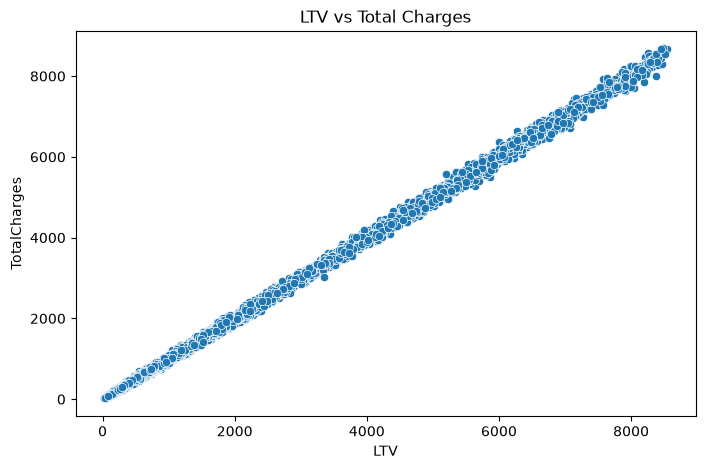

In [9]:
#Visualize:

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="LTV",
    y="TotalCharges",
    data=df
)

plt.title("LTV vs Total Charges")
plt.show()

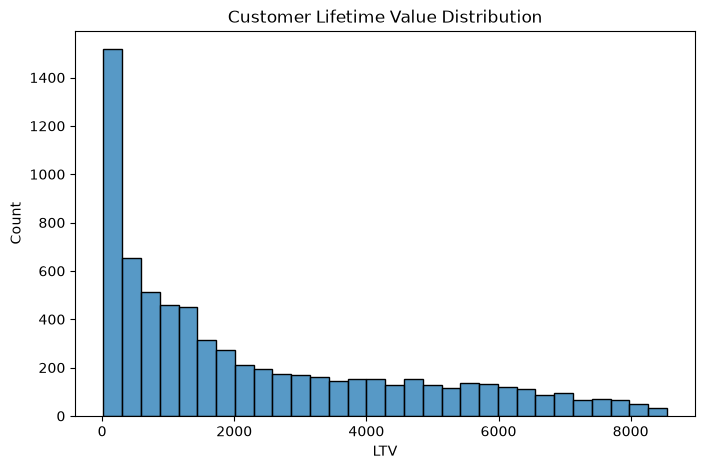

In [10]:
#Plot LTV Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["LTV"],
    bins=30
)

plt.title("Customer Lifetime Value Distribution")
plt.show()

In [11]:
#Identify Top Customers

top_ltv = df.sort_values(
    by="LTV",
    ascending=False
)

top_ltv[
    [
        "customerID",
        "MonthlyCharges",
        "tenure",
        "LTV"
    ]
].head(10)

,customerID,MonthlyCharges,tenure,LTV
4586,7569-NMZYQ,118.75,72,8550.00
6118,9924-JPRMC,118.20,72,8510.40
4610,2889-FPWRM,117.80,72,8481.60
3205,3810-DVDQQ,117.60,72,8467.20
6768,9739-JLPQJ,117.50,72,8460.00
4155,6904-JLBGY,117.35,72,8449.20
2368,6650-BWFRT,117.15,72,8434.80
2115,8984-HPEMB,118.65,71,8424.15
5347,9788-HNGUT,116.95,72,8420.40
2025,1488-PBLJN,116.85,72,8413.20


In [12]:
#Create LTV Segments
#Segment customers into groups

df["LTVSegment"] = pd.qcut(
    df["LTV"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [13]:
#Check counts:

df["LTVSegment"].value_counts()

LTVSegment
Low       2344
Medium    2344
High      2344
Name: count, dtype: int64

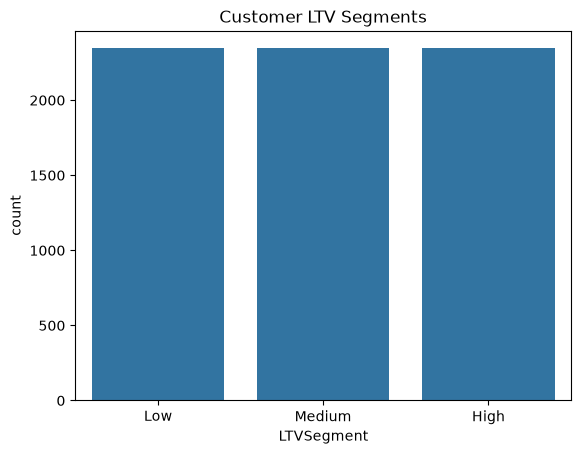

In [14]:
#Visualize LTV Segments

sns.countplot(
    x="LTVSegment",
    data=df
)

plt.title("Customer LTV Segments")
plt.show()

In [15]:
#Save Processed Dataset

df.to_csv(
    "../data/processed/customer_ltv_v1.csv",
    index=False
)